<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Syntetic_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
#Generate a 2D dataset with two clusters

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define parameters for Cluster 1
center_c1 = [5, 5]
var_c1 = [3, 1] # var_x, var_y
std_c1 = np.sqrt(var_c1)

# Define parameters for Cluster 2
center_c2 = [15, 15]
var_c2 = [1, 3] # var_x, var_y
std_c2 = np.sqrt(var_c2)

# Number of points per cluster
num_points_per_cluster = 200

# Generate data for Cluster 1
data_c1_x = np.random.normal(center_c1[0], std_c1[0], num_points_per_cluster)
data_c1_y = np.random.normal(center_c1[1], std_c1[1], num_points_per_cluster)
data_c1 = np.column_stack((data_c1_x, data_c1_y))

# Generate data for Cluster 2
data_c2_x = np.random.normal(center_c2[0], std_c2[0], num_points_per_cluster)
data_c2_y = np.random.normal(center_c2[1], std_c2[1], num_points_per_cluster)
data_c2 = np.column_stack((data_c2_x, data_c2_y))

# Combine the data
dataset = np.vstack((data_c1, data_c2))

# Create a DataFrame for better handling and display
df = pd.DataFrame(dataset, columns=['X', 'Y'])
display(df.head(),df.tail())


,X,Y
0,4.306394,5.343825
1,1.372085,4.370015
2,4.147196,5.315740
3,3.896165,6.915742
4,4.863828,5.773854


,X,Y
395,15.574881,15.651023
396,14.926028,11.959284
397,14.301977,15.896646
398,17.473231,13.869013
399,15.482571,17.519842


Now, let's visualize the generated dataset to see the two clusters.

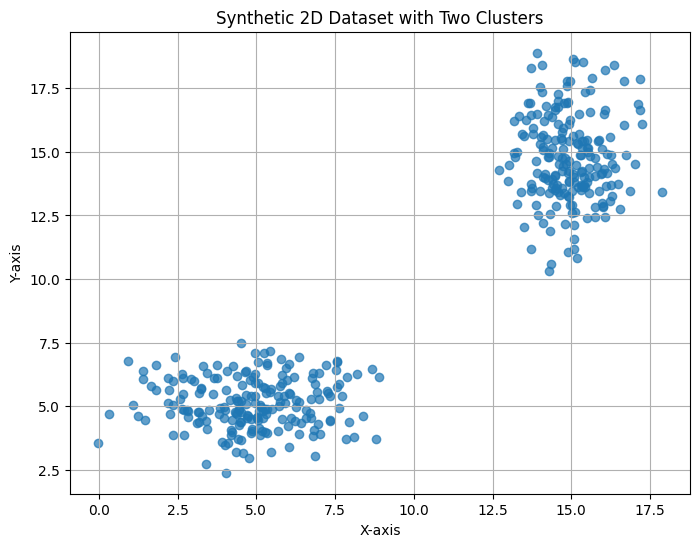

In [26]:
# Draw the dataset

plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], alpha=0.7)
plt.title('Synthetic 2D Dataset with Two Clusters')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()


In [38]:
# Transform the dataset to categorical through binning

import pandas as pd

# Define ordinal labels
ordinal_labels = ['VL', 'L', 'M', 'H', 'VH']

# Calculate bin edges for X
min_x, max_x = df['X'].min(), df['X'].max()
bins_x = np.linspace(min_x, max_x, num=6) # 6 edges for 5 bins

# Calculate bin edges for Y
min_y, max_y = df['Y'].min(), df['Y'].max()
bins_y = np.linspace(min_y, max_y, num=6) # 6 edges for 5 bins

# Create a new DataFrame for ordinal variables
df_ordinal = pd.DataFrame()

# Apply equal-width binning for X and Y and map to ordinal labels
df_ordinal['X_ordinal'] = pd.cut(df['X'], bins=bins_x, labels=ordinal_labels, include_lowest=True)
df_ordinal['Y_ordinal'] = pd.cut(df['Y'], bins=bins_y, labels=ordinal_labels, include_lowest=True)

# Display the head of the new ordinal DataFrame
display(df_ordinal.head(),df_ordinal.tail())


,X_ordinal,Y_ordinal
0,L,VL
1,L,L
2,L,L
3,VL,VL
4,VL,VL


,X_ordinal,Y_ordinal
395,VH,H
396,VH,H
397,VH,H
398,VH,H
399,VH,M


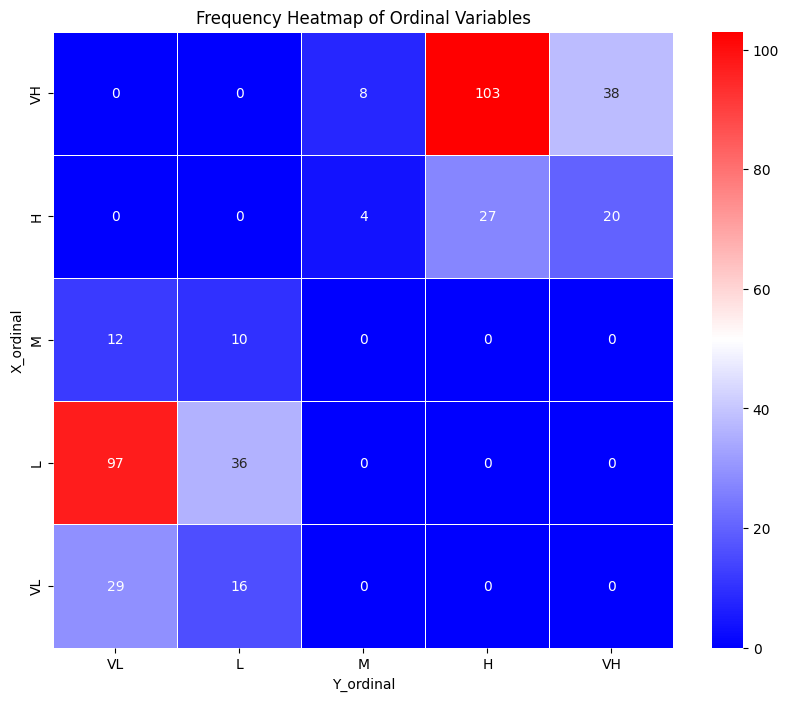

In [28]:
# Visualize the categorical dataset heatmap

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate the frequency of each combination of encoded ordinal variables
frequency_table_ordinal_encoded = pd.crosstab(df_ordinal['X_ordinal'],df_ordinal['Y_ordinal'])

# Reindex both rows and columns to ensure correct ordering for visualization (VL bottom-left)
# The index (y-axis) needs to be reversed so 'VL' is at the bottom
# The columns (x-axis) should be in the natural order 'VL' to 'VH'
ordered_index = ordinal_labels[::-1] # ['VH', 'H', 'M', 'L', 'VL']
ordered_columns = ordinal_labels     # ['VL', 'L', 'M', 'H', 'VH']

frequency_table_for_heatmap = frequency_table_ordinal_encoded.reindex(index=ordered_index, columns=ordered_columns)
frequency_table_for_heatmap = frequency_table_for_heatmap.fillna(0).astype(int) # Fill NaNs and convert to int

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(frequency_table_for_heatmap, annot=True, fmt='d', cmap='bwr', linewidths=.5)
plt.title('Frequency Heatmap of Ordinal Variables')
plt.xlabel('Y_ordinal') # X-axis corresponds to Y_ordinal in the crosstab result
plt.ylabel('X_ordinal') # Y-axis corresponds to X_ordinal in the crosstab result

# The xticks and yticks can now directly use the ordered labels,
# as the DataFrame itself is ordered for the heatmap.
plt.xticks(ticks=np.arange(len(ordered_columns)) + 0.5, labels=ordered_columns)
plt.yticks(ticks=np.arange(len(ordered_index)) + 0.5, labels=ordered_index)
plt.show()

In [37]:
#Copy the dataset

import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Create a copy of df_ordinal
df_ordinal_copy = df_ordinal.copy()

# Display the head of the copied DataFrame to verify
display(df_ordinal_copy.head(),df_ordinal_copy.tail())


,X_ordinal,Y_ordinal
0,L,VL
1,L,L
2,L,L
3,VL,VL
4,VL,VL


,X_ordinal,Y_ordinal
395,VH,H
396,VH,H
397,VH,H
398,VH,H
399,VH,M


In [40]:
#Apply Label Encoding

import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_ordinal_copy['X-encoded-label'] = le.fit_transform(df_ordinal_copy['X_ordinal'])
df_ordinal_copy['Y-encoded-label'] = le.fit_transform(df_ordinal_copy['Y_ordinal'])

# Display the head of the DataFrame with encoded values
display(df_ordinal_copy.head(),df_ordinal_copy.tail())

,X_ordinal,Y_ordinal,X-encoded-label,Y-encoded-label
0,L,VL,1,4
1,L,L,1,1
2,L,L,1,1
3,VL,VL,4,4
4,VL,VL,4,4


,X_ordinal,Y_ordinal,X-encoded-label,Y-encoded-label
395,VH,H,3,0
396,VH,H,3,0
397,VH,H,3,0
398,VH,H,3,0
399,VH,M,3,2


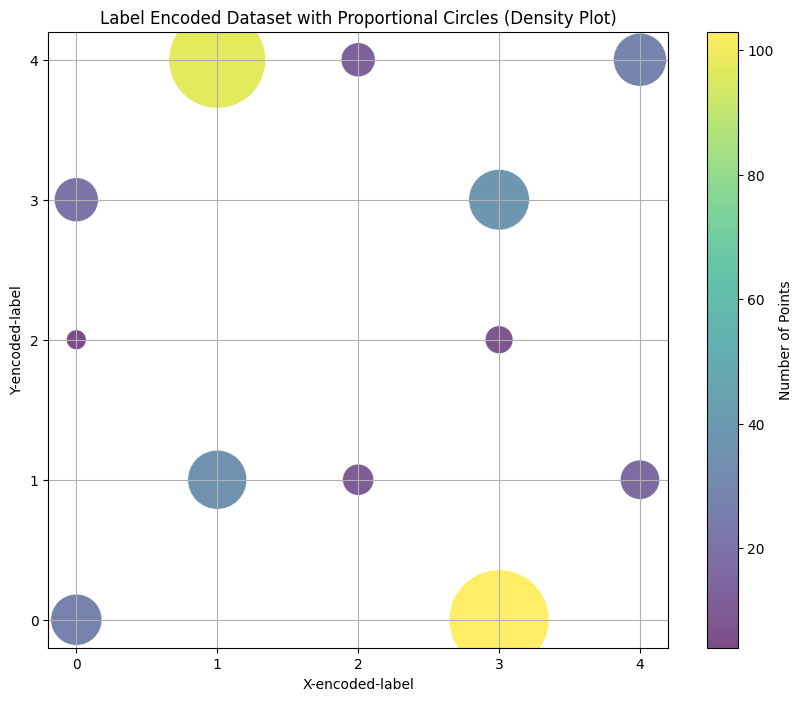

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by encoded label values and count occurrences
frequency_df = df_ordinal_copy.groupby(['X-encoded-label', 'Y-encoded-label']).size().reset_index(name='count')

# Calculate size for markers. We can scale this as needed.
# For example, by multiplying by a constant or using a log scale.
size_multiplier = 50 # Adjust this value to make circles more visible or smaller
frequency_df['marker_size'] = frequency_df['count'] * size_multiplier

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    frequency_df['X-encoded-label'],
    frequency_df['Y-encoded-label'],
    s=frequency_df['marker_size'], # Use the calculated marker size
    alpha=0.7,
    c=frequency_df['count'], # Color by count for additional visual cue
    cmap='viridis', # Choose a colormap
    edgecolors='w', # Add white edges for better separation
    linewidth=0.5
)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Points')

plt.title('Label Encoded Dataset with Proportional Circles (Density Plot)')
plt.xlabel('X-encoded-label')
plt.ylabel('Y-encoded-label')
plt.grid(True)

# Set integer ticks for ordinal scales
plt.xticks(sorted(df_ordinal_copy['X-encoded-label'].unique()))
plt.yticks(sorted(df_ordinal_copy['Y-encoded-label'].unique()))

plt.show()

Questo grafico scatter ora mostra la densità dei punti dati. La dimensione di ogni cerchio è proporzionale al numero di osservazioni che hanno la stessa combinazione di `X_encoded_ordinal` e `Y_encoded_ordinal`. I colori indicano anch'essi la frequenza, con una barra di colore per la legenda.

Finally, let's visualize the heatmap of the label-encoded variables.

In [36]:
#Copy back the dataset

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1) Create a copy of df_ordinal
df_ordinal_copy = df_ordinal.copy()

# Display the head of the copied DataFrame to verify
display(df_ordinal_copy.head(),df_ordinal_copy.tail())


,X_ordinal,Y_ordinal
0,L,VL
1,L,L
2,L,L
3,VL,VL
4,VL,VL


,X_ordinal,Y_ordinal
395,VH,H
396,VH,H
397,VH,H
398,VH,H
399,VH,M


Now, let's apply Ordinal Encoding to the copied DataFrame, preserving the specific order of the categories.

In [35]:
# Apply Ordinal Encoding

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Define the ordered categories for the ordinal encoder
ordinal_categories = [['VL', 'L', 'M', 'H', 'VH']]

# 2) Apply Ordinal Encoding
oe = OrdinalEncoder(categories=ordinal_categories)
df_ordinal_copy['X_encoded_ordinal'] = oe.fit_transform(df_ordinal_copy[['X_ordinal']])
df_ordinal_copy['Y_encoded_ordinal'] = oe.fit_transform(df_ordinal_copy[['Y_ordinal']])

# Display the head of the DataFrame with encoded values
display(df_ordinal_copy.head(),df_ordinal_copy.tail())


,X_ordinal,Y_ordinal,X_encoded_ordinal,Y_encoded_ordinal
0,L,VL,1.0,0.0
1,L,L,1.0,1.0
2,L,L,1.0,1.0
3,VL,VL,0.0,0.0
4,VL,VL,0.0,0.0


,X_ordinal,Y_ordinal,X_encoded_ordinal,Y_encoded_ordinal
395,VH,H,4.0,3.0
396,VH,H,4.0,3.0
397,VH,H,4.0,3.0
398,VH,H,4.0,3.0
399,VH,M,4.0,2.0


Finally, let's visualize the heatmap of the ordinally encoded variables.

Now, let's visualize the new numerical ordinal dataset with a scatter plot.

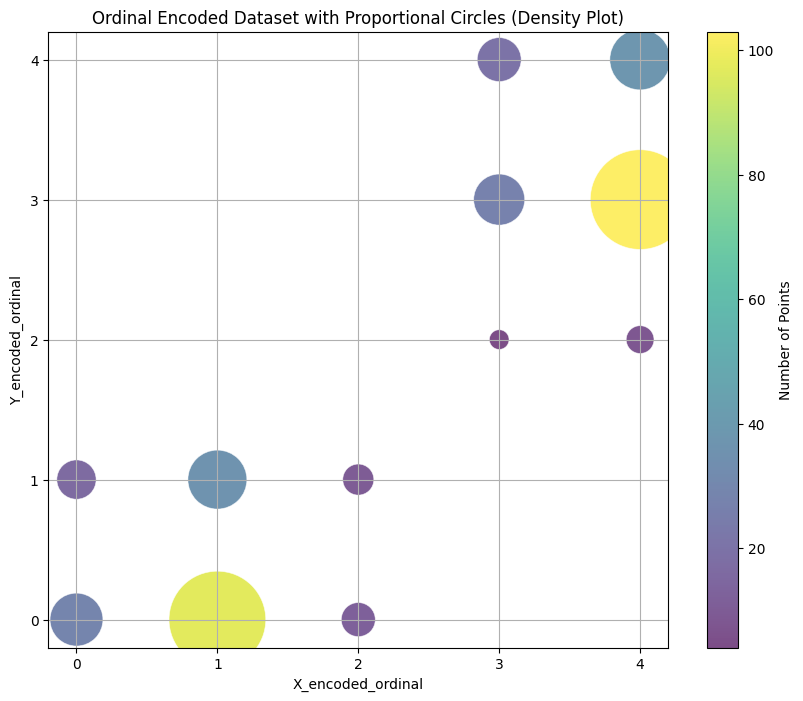

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Define the ordered categories for the ordinal encoder (needed if df_ordinal_copy was reset)
ordinal_categories = [['VL', 'L', 'M', 'H', 'VH']]

# Re-apply Ordinal Encoding to ensure columns exist in the current df_ordinal_copy state
oe = OrdinalEncoder(categories=ordinal_categories)
df_ordinal_copy['X_encoded_ordinal'] = oe.fit_transform(df_ordinal_copy[['X_ordinal']])
df_ordinal_copy['Y_encoded_ordinal'] = oe.fit_transform(df_ordinal_copy[['Y_ordinal']])

# Group by encoded ordinal values and count occurrences
frequency_df = df_ordinal_copy.groupby(['X_encoded_ordinal', 'Y_encoded_ordinal']).size().reset_index(name='count')

# Calculate size for markers. We can scale this as needed.
# For example, by multiplying by a constant or using a log scale.
size_multiplier = 50 # Adjust this value to make circles more visible or smaller
frequency_df['marker_size'] = frequency_df['count'] * size_multiplier

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    frequency_df['X_encoded_ordinal'],
    frequency_df['Y_encoded_ordinal'],
    s=frequency_df['marker_size'], # Use the calculated marker size
    alpha=0.7,
    c=frequency_df['count'], # Color by count for additional visual cue
    cmap='viridis', # Choose a colormap
    edgecolors='w', # Add white edges for better separation
    linewidth=0.5
)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Points')

plt.title('Ordinal Encoded Dataset with Proportional Circles (Density Plot)')
plt.xlabel('X_encoded_ordinal')
plt.ylabel('Y_encoded_ordinal')
plt.grid(True)

# Set integer ticks for ordinal scales
plt.xticks(sorted(df_ordinal_copy['X_encoded_ordinal'].unique()))
plt.yticks(sorted(df_ordinal_copy['Y_encoded_ordinal'].unique()))

plt.show()